=== First 5 Rows ===
      name  math  science  english  history  pe  attendance_pct  \
0    Alice    88       92       76       80  95              92   
1      Bob    42       55       48       50  60              65   
2  Charlie    75       70       80       68  88              85   
3    Diana    95       98       91       89  97              98   
4      Eve    38       42       50       45  55              58   

   study_hours_per_day  passed  
0                  4.5       1  
1                  1.2       0  
2                  3.0       1  
3                  6.0       1  
4                  0.8       0  

Shape: 15 rows × 9 columns

Column data types:
name                    object
math                     int64
science                  int64
english                  int64
history                  int64
pe                       int64
attendance_pct           int64
study_hours_per_day    float64
passed                   int64
dtype: object

=== Summary Statistics ===
        m

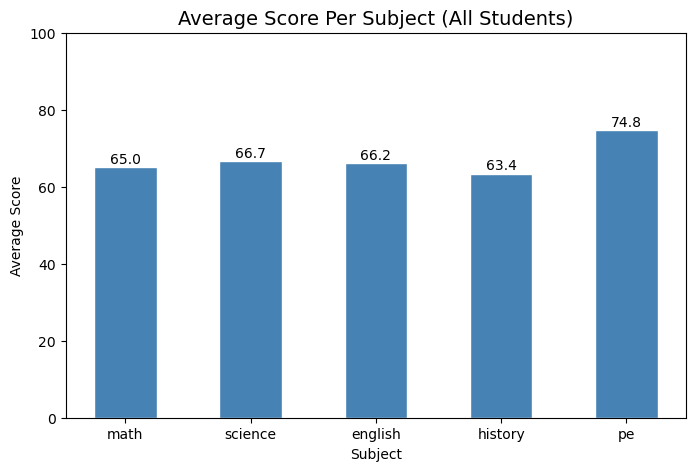

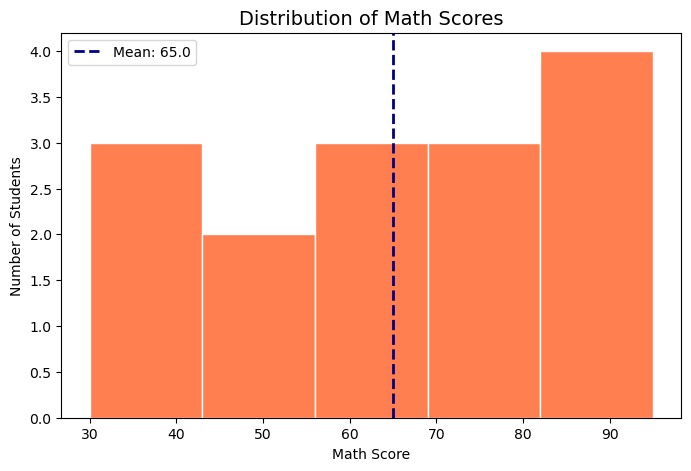

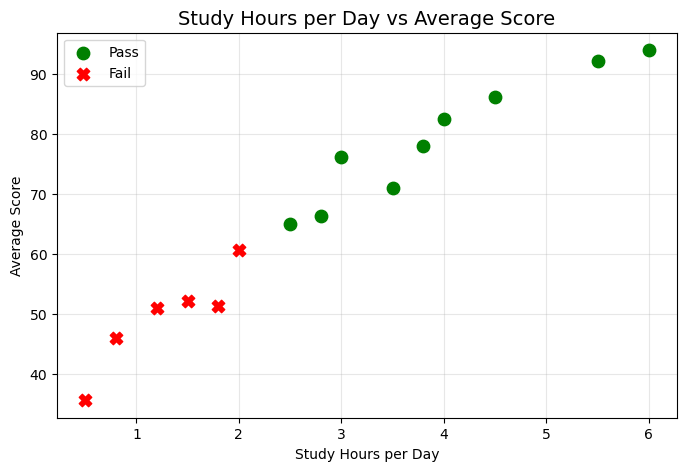

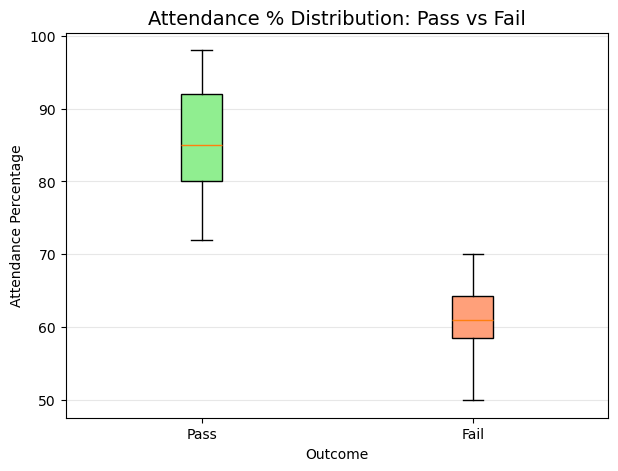

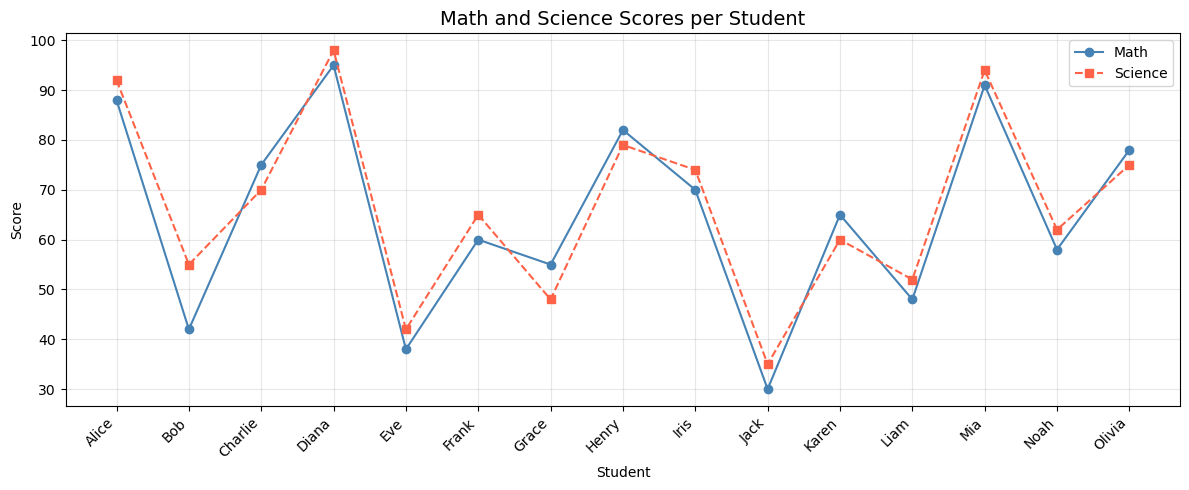

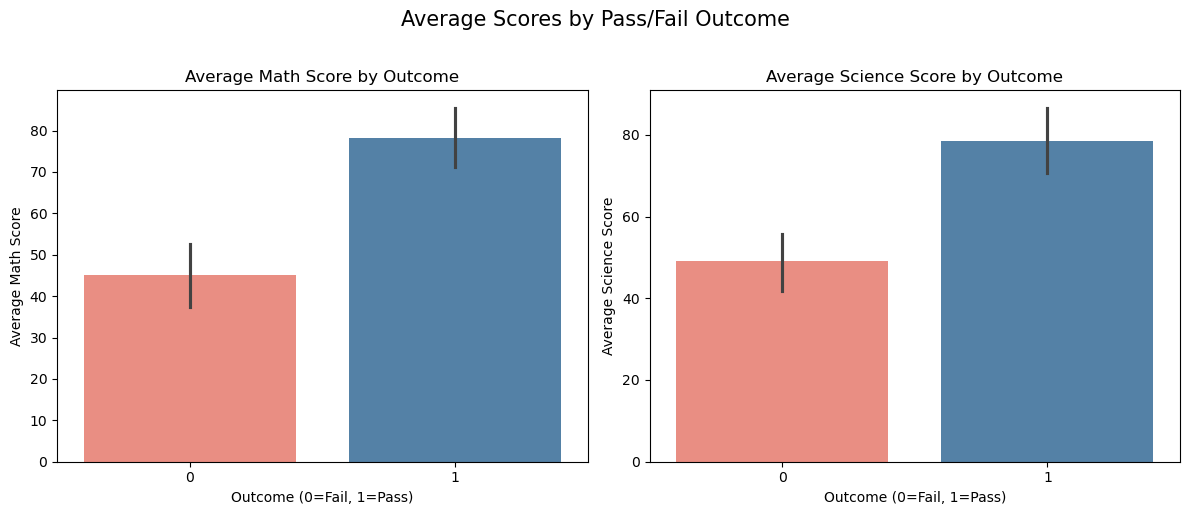

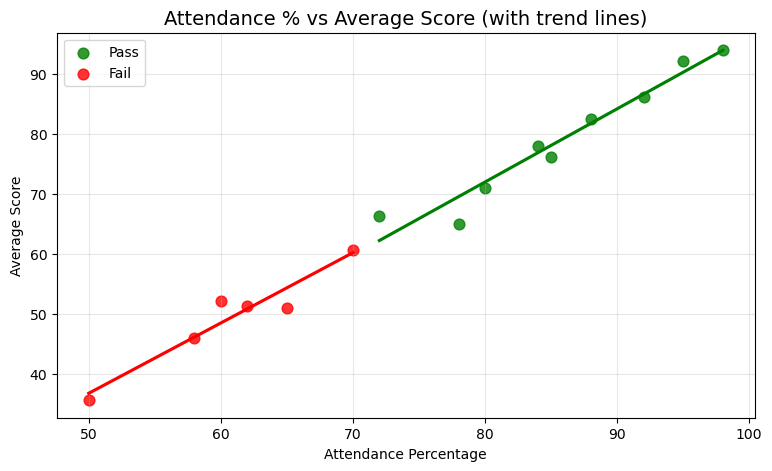

Training samples: 12
Test samples: 3

Training accuracy: 100.00%
Test accuracy: 100.00%

Name           Actual  Predicted   Result
--------------------------------------------
Jack             Fail       Fail        ✅
Liam             Fail       Fail        ✅
Alice            Pass       Pass        ✅

Feature                    Coefficient
--------------------------------------
  english                    +0.8125  → Pass
  attendance_pct             +0.5219  → Pass
  study_hours_per_day        +0.4844  → Pass
  pe                         +0.4750  → Pass
  math                       +0.4379  → Pass
  science                    +0.3230  → Pass
  history                    +0.2629  → Pass


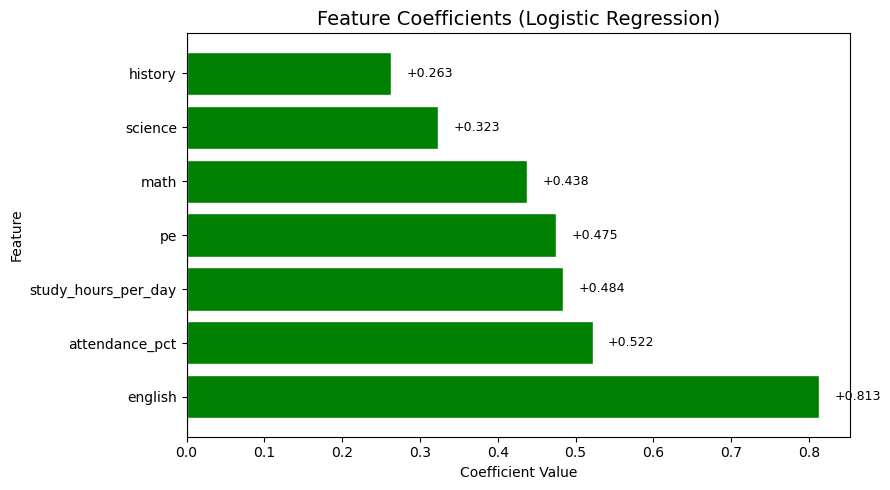

/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(



--- Bonus: New Student Prediction ---
  Prediction       : Pass ✅
  Probability Fail : 9.20%
  Probability Pass : 90.80%


In [15]:
#-------------------------------------------- Task 1 — Data Exploration with Pandas ----------------------------------------------------
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing   import StandardScaler
from sklearn.linear_model    import LogisticRegression
from sklearn.metrics         import accuracy_score

df = pd.read_csv("students.csv")

#Print the first 5 rows using .head()
print("=== First 5 Rows ===")
print(df.head())

#Print the shape (rows × columns) and the data type of each column using .dtypes
print(f"\nShape: {df.shape[0]} rows × {df.shape[1]} columns")
print("\nColumn data types:")
print(df.dtypes)

#Print summary statistics (mean, min, max, std) for all numeric columns using .describe()
print("\n=== Summary Statistics ===")
print(df.describe().round(2))

#Print the count of students who passed and who failed
print("\n=== Pass / Fail Count ===")
print(df['passed'].value_counts().rename({1: 'Pass', 0: 'Fail'}))

#Compute and print the average score per subject(math, science, english, history, pe) separately for passing and failing students
subject_cols = ['math', 'science', 'english', 'history', 'pe']

pass_avg = df[df['passed'] == 1][subject_cols].mean()
fail_avg = df[df['passed'] == 0][subject_cols].mean()

print("\n=== Average Subject Scores ===")
print(f"{'Subject':<12} {'Pass Avg':>10} {'Fail Avg':>10}")
print("-" * 34)
for subject in subject_cols:
    print(f"{subject:<12} {pass_avg[subject]:>10.2f} {fail_avg[subject]:>10.2f}")

#Find and print the student with the highest overall average across all 5 subjects
df['temp_avg'] = df[subject_cols].mean(axis=1)
top_idx     = df['temp_avg'].idxmax()
print(f"\nTop student: {df.loc[top_idx, 'name']} "
      f"(avg score: {df.loc[top_idx, 'temp_avg']:.2f})")
df = df.drop(columns=['temp_avg'])

#-------------------------------------------------------- Task 2 — Data Visualization with Matplotlib -----------------------------------
subject_cols = ['math', 'science', 'english', 'history', 'pe']
df['avg_score'] = df[subject_cols].mean(axis=1)

#Bar Chart — Average score per subject across all students (one bar per subject, x-axis = subject name, y-axis = average score)
subject_avgs = df[subject_cols].mean()                       #every subject's average

fig, ax = plt.subplots(figsize=(8, 5))

ax.bar(subject_avgs.index,    # x is subject names
       subject_avgs.values,   # bar heights indicate average scores
       color='steelblue',
       edgecolor='white',
       width=0.5)

ax.set_title("Average Score Per Subject (All Students)", fontsize=14)
ax.set_xlabel("Subject")
ax.set_ylabel("Average Score")
ax.set_ylim(0, 100)

#adding value labels on top of each bar
for i, val in enumerate(subject_avgs.values):
    ax.text(i, val + 1, f"{val:.1f}", ha='center', fontsize=10)

plt.savefig("plot1_bar.png", bbox_inches='tight', dpi=150)
plt.show()
plt.close()
#Histogram — Distribution of math scores. Use 5 bins. Add a vertical dashed line at the mean math score and label it.
math_mean = df['math'].mean()
fig, ax = plt.subplots(figsize=(8, 5))
#bins =5 divides the range into 5 equal buckets
ax.hist(df['math'],bins=5,color='coral',edgecolor='white')
#Vertical dashed line at the mean
ax.axvline(math_mean,color='navy',linestyle='--',linewidth=2,label=f'Mean: {math_mean:.1f}')
ax.set_title("Distribution of Math Scores", fontsize=14)
ax.set_xlabel("Math Score")
ax.set_ylabel("Number of Students")
ax.legend()
plt.savefig("plot2_histogram.png", bbox_inches='tight', dpi=150)
plt.show()
plt.close()

#Scatter Plot-study_hours_per_day(x-axis) vs avg_score(y-axis).
#Each point coloured differently based on passed. 
#Include a legend.

#splittting into two groups for different colours for Pass and Fail
pass_df = df[df['passed'] == 1]
fail_df = df[df['passed'] == 0]
fig,ax = plt.subplots(figsize=(8, 5))

#plotting each group separately for different colours + legend
ax.scatter(pass_df['study_hours_per_day'],pass_df['avg_score'],color='green',label='Pass',s=80,zorder=3)
ax.scatter(fail_df['study_hours_per_day'],fail_df['avg_score'],color='red',label='Fail',s=80,zorder=3,marker='X')
ax.set_title("Study Hours per Day vs Average Score",fontsize=14)
ax.set_xlabel("Study Hours per Day")
ax.set_ylabel("Average Score")
ax.legend()
ax.grid(True,alpha=0.3)
plt.savefig("plot3_scatter.png",bbox_inches='tight',dpi=150)
plt.show()
plt.close()

#Box Plot — Show the distribution of attendance_pct for passing students vs failing students side by side.
pass_attendance = df[df['passed'] == 1]['attendance_pct'].tolist()
fail_attendance = df[df['passed'] == 0]['attendance_pct'].tolist()
fig, ax = plt.subplots(figsize=(7, 5))
bp = ax.boxplot([pass_attendance,fail_attendance],labels=['Pass','Fail'],patch_artist=True)  #fill with colour

#colour the boxes
bp['boxes'][0].set_facecolor('lightgreen')
bp['boxes'][1].set_facecolor('lightsalmon')
ax.set_title("Attendance % Distribution: Pass vs Fail",fontsize=14)
ax.set_xlabel("Outcome")
ax.set_ylabel("Attendance Percentage")
ax.grid(True, axis='y',alpha=0.3)
plt.savefig("plot4_boxplot.png",bbox_inches='tight',dpi=150)
plt.show()
plt.close()


#Line Plot — Plot the math score and science score for every student. 
#X-axis = student name, Y-axis = score. 
#Use different line styles or markers for each subject.

names = df['name'].tolist()
x_pos = range(len(names))

fig,ax = plt.subplots(figsize=(12,5))
ax.plot(x_pos, df['math'],marker='o',linestyle='-',color='steelblue',label='Math')
ax.plot(x_pos, df['science'],marker='s',linestyle='--',color='tomato',label='Science')

#replace numeric x-tick positions with student names rotated to fit
ax.set_xticks(x_pos)
ax.set_xticklabels(names, rotation=45, ha='right')
ax.set_title("Math and Science Scores per Student", fontsize=14)
ax.set_xlabel("Student")
ax.set_ylabel("Score")
ax.legend()
ax.grid(True,alpha=0.3)
plt.tight_layout()   #to not cut off rotated labels 
plt.savefig("plot5_line.png", bbox_inches='tight', dpi=150)
plt.show()
plt.close()

#---------------------------------------- Task 3 — Data Visualization with Seaborn -----------------------------------

#Create a Seaborn bar plot showing the average math score and average science score, split by passed (Pass vs Fail).
#Use two separate sns.barplot() calls — one for math, one for science — on the same figure using plt.subplot().

fig,(ax1,ax2) = plt.subplots(1,2,figsize=(12,5))
sns.barplot(data=df, x='passed', y='math',hue='passed',palette={0: 'salmon', 1: 'steelblue'},ax=ax1,legend=False)
ax1.set_title("Average Math Score by Outcome")
ax1.set_xlabel("Outcome (0=Fail, 1=Pass)")
ax1.set_ylabel("Average Math Score")
sns.barplot(data=df, x='passed', y='science',hue='passed',palette={0: 'salmon', 1: 'steelblue'},ax=ax2, legend=False)
ax2.set_title("Average Science Score by Outcome")
ax2.set_xlabel("Outcome (0=Fail, 1=Pass)")
ax2.set_ylabel("Average Science Score")
plt.suptitle("Average Scores by Pass/Fail Outcome", fontsize=15, y=1.02)
plt.tight_layout()
plt.savefig("plot6_seaborn_bar.png", bbox_inches='tight', dpi=150)
plt.show()
plt.close()

#Create a Seaborn scatter plot of attendance_pct (x-axis) vs avg_score (y-axis), coloured by passed.
#Add a regression line using sns.regplot() for each group (Pass and Fail) on the same axes.

fig, ax = plt.subplots(figsize=(9, 5))
#regression line
sns.regplot(data=df[df['passed'] == 1],x='attendance_pct', y='avg_score',label='Pass',color='green',scatter_kws={'s': 60},ci=None,ax=ax)
sns.regplot(data=df[df['passed'] == 0],x='attendance_pct', y='avg_score',label='Fail',color='red',scatter_kws={'s': 60},ci=None,ax=ax)
ax.set_title("Attendance % vs Average Score (with trend lines)", fontsize=14)
ax.set_xlabel("Attendance Percentage")
ax.set_ylabel("Average Score")
ax.legend()
ax.grid(True, alpha=0.3)
plt.savefig("plot7_seaborn_regression.png", bbox_inches='tight', dpi=150)
plt.show()
plt.close()

################################## Required Assignment Comment - Seaborn vs Matplotlib ##########################################
#Write 2–3 sentences as a comment in your code comparing your experience of using Seaborn vs Matplotlib for these plots 
#(e.g., what was easier, what required more work).

#Seaborn was easier as I didn't have to manually compute group averages. Matplotlib required manual calculation.

#Matplotlib allowed more creative control over the graphical elements I think.


# ------------------------------------------------ Task 4 — Machine Learning with scikit-learn -----------------------------

#Step 1 — Prepare Data:

#Separate features and target
#Keep the original df intact
feature_cols = ['math','science','english','history','pe','attendance_pct','study_hours_per_day']
X = df[feature_cols]
y = df['passed']

#Split into train (80%) and test (20%) sets:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#Scale features using StandardScaler — fit on training data only, then transform both sets
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"Training samples: {len(X_train)}")
print(f"Test samples: {len(X_test)}")

#Step 2 — Train a Model:
model = LogisticRegression(random_state=42, max_iter=1000)
model.fit(X_train_scaled, y_train)
print(f"\nTraining accuracy: {model.score(X_train_scaled, y_train):.2%}")

#Step 3 — Evaluate the Model:
#Predict on the test set
y_pred = model.predict(X_test_scaled)
#Print the test accuracy
print(f"Test accuracy: {accuracy_score(y_test, y_pred):.2%}")

#For each student in the test set, print their name alongside the actual label and predicted label
test_names = df.loc[X_test.index, 'name']
print(f"\n{'Name':<12} {'Actual':>8} {'Predicted':>10} {'Result':>8}")
print("-" * 44)
#print whether the prediction was ✅ correct or ❌ wrong
for name, actual, predicted in zip(test_names, y_test, y_pred):
    a = "Pass" if actual    == 1 else "Fail"
    p = "Pass" if predicted == 1 else "Fail"
    r = "✅" if actual == predicted else "❌"
    print(f"{name:<12} {a:>8} {p:>10} {r:>8}")

#Step 4 — Feature Importance:
#Extract the model coefficients: model.coef_[0] — these are one value per feature
coefficients = model.coef_[0]

#Pair each coefficient with its feature name and print them, sorted by absolute value (largest first).
feat_imp = sorted(zip(feature_cols,coefficients),key=lambda x: abs(x[1]),reverse=True)
print(f"\n{'Feature':<25} {'Coefficient':>12}")
print("-" * 38)
for feat, coef in feat_imp:
    print(f"  {feat:<23} {coef:>+10.4f}  {'→ Pass' if coef > 0 else '→ Fail'}")

#Create a horizontal bar chart using Matplotlib showing all feature coefficients.
fig, ax = plt.subplots(figsize=(9, 5))

feats   = [f[0] for f in feat_imp]
coefs   = [f[1] for f in feat_imp]

# Use different colours for positive (green) and negative (red) coefficients. 
colours = ['green' if c > 0 else 'red' for c in coefs]
bars    = ax.barh(feats, coefs, color=colours, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)

#Add a title and axis labels.
ax.set_title("Feature Coefficients (Logistic Regression)", fontsize=14)
ax.set_xlabel("Coefficient Value")
ax.set_ylabel("Feature")

#A positive coefficient means that feature pushes the prediction towards Pass; a negative one pushes towards Fail.
for bar, coef in zip(bars, coefs):
    ax.text(coef + (0.02 if coef >= 0 else -0.02),bar.get_y() + bar.get_height() / 2,
            f"{coef:+.3f}",va='center',ha='left' if coef >= 0 else 'right',fontsize=9)
plt.tight_layout()
plt.savefig("plot8_coefficients.png",bbox_inches='tight',dpi=150)
plt.show()
plt.close()

#Step 5 — Predict for a New Student (Bonus — 2 marks)
new_student = [[75, 70, 68, 65, 80, 82, 3.2]]  # order must match feature columns

#Scale it using scaler.transform(new_student)
new_scaled  = scaler.transform(new_student)

#Predict using model.predict()
prediction  = model.predict(new_scaled)[0]

#display the probability using model.predict_proba()
probability = model.predict_proba(new_scaled)[0]
outcome     = "Pass ✅" if prediction == 1 else "Fail ❌"

#Print whether the model predicts Pass or Fail
print(f"\n--- Bonus: New Student Prediction ---")
print(f"  Prediction       : {outcome}")
print(f"  Probability Fail : {probability[0]:.2%}")
print(f"  Probability Pass : {probability[1]:.2%}")


